<a href="https://colab.research.google.com/github/code-with-maira/evolvix-aiml-internship-maira/blob/main/week-1/task-1/titanic_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loading Data**

I start by importing the required libraries: **pandas** for data handling, **seaborn** and **matplotlib** for visualizations. I also set a clean seaborn theme so all charts share the same style.
The Titanic dataset is then loaded directly from a public URL using `pd.read_csv()`, so no file upload is needed. The printed shape confirms the data has loaded: **891 rows and 12 columns**.

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (891, 12)


Looking at the first few rows in dataset

In [48]:
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Information about the Dataset

In [49]:
print("Shape:", df.shape)
df.info()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Missing values heatmap

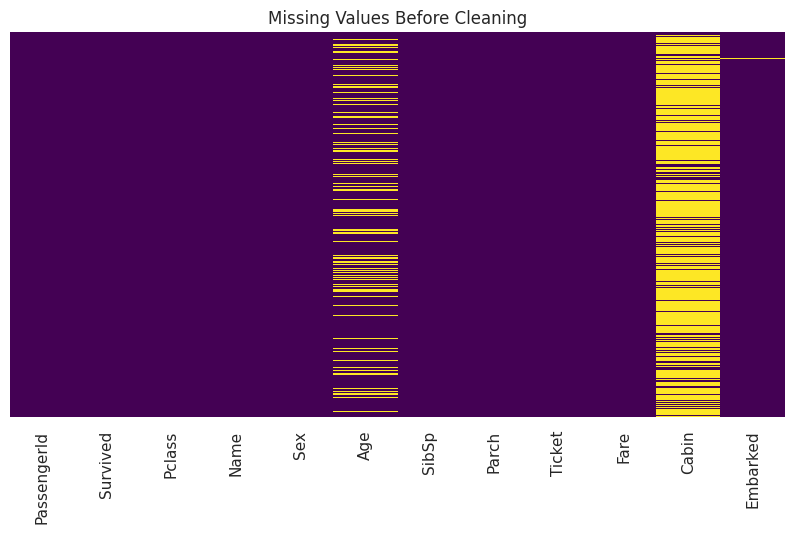

In [50]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values Before Cleaning")
plt.show()

In [51]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Observation:**
- Only about 38% of passengers survived.
- The average age was about 30 years.
- The most expensive ticket was about 512.

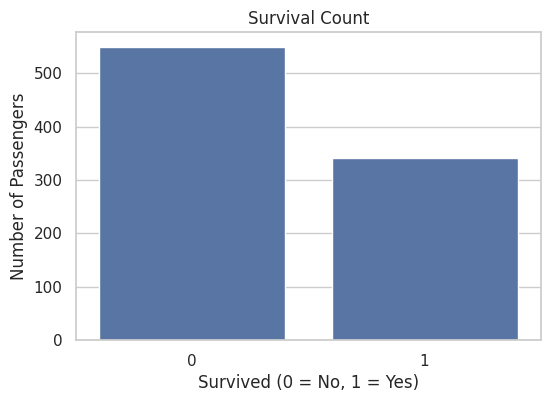

In [52]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

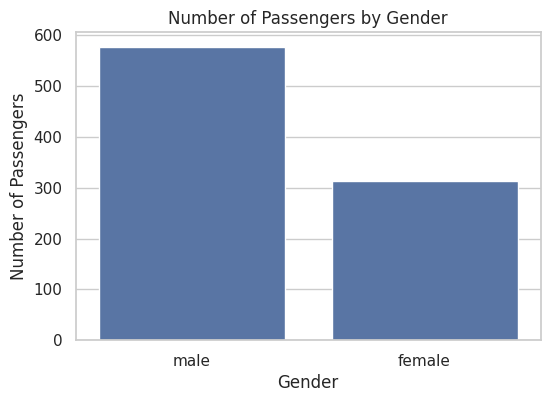

In [53]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", data=df)
plt.title("Number of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

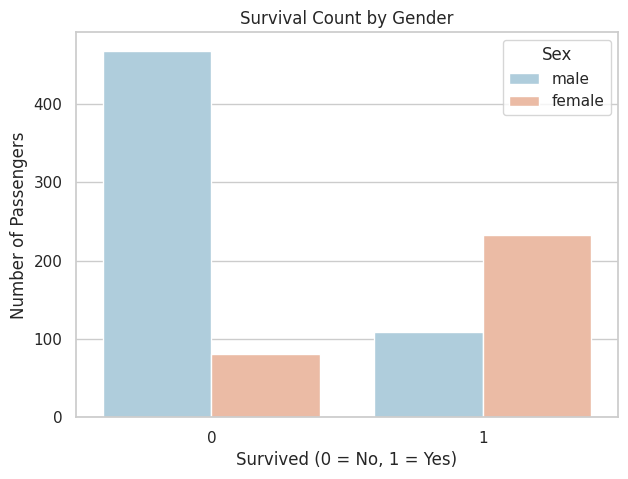

In [54]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Survived", hue="Sex", data=df, palette="RdBu_r")
plt.title("Survival Count by Gender")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

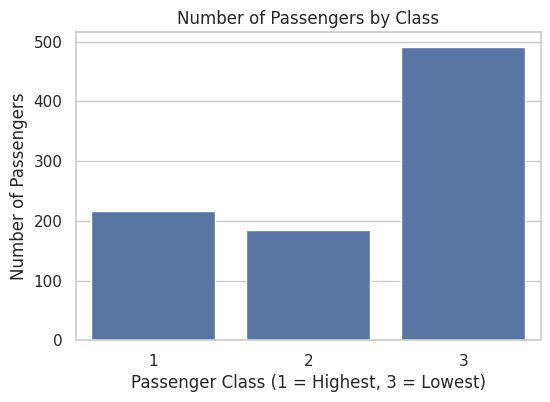

In [55]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", data=df)
plt.title("Number of Passengers by Class")
plt.xlabel("Passenger Class (1 = Highest, 3 = Lowest)")
plt.ylabel("Number of Passengers")
plt.show()

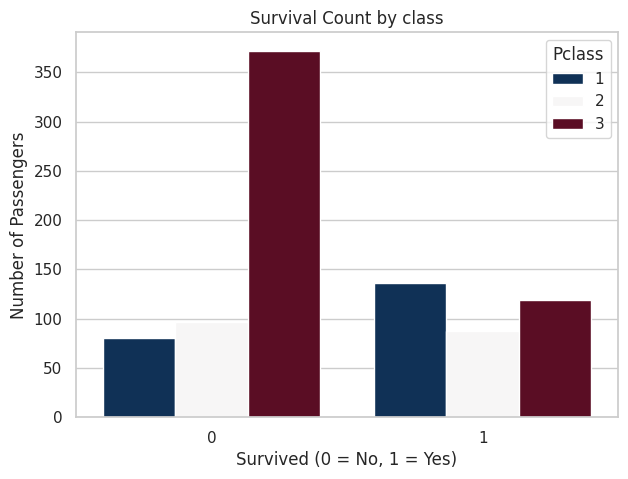

In [56]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Survived", hue="Pclass", data=df, palette="RdBu_r")
plt.title("Survival Count by class")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

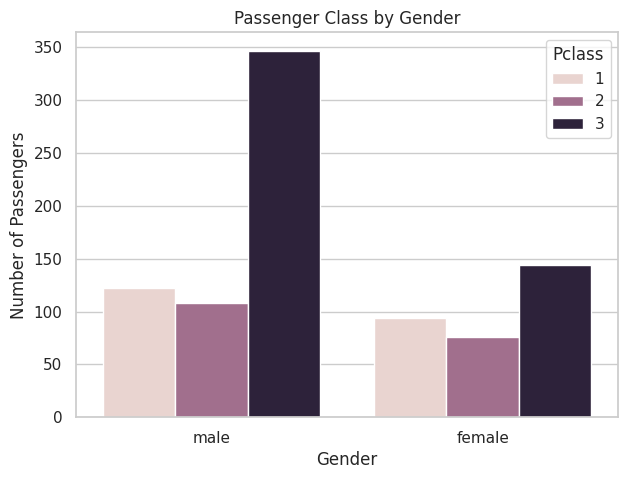

In [57]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Sex", hue="Pclass", data=df)
plt.title("Passenger Class by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

**Observation:** Men made up the largest share of 3rd class (about 347 men vs 144 women). This is partly why the overall survival rate of men was lower, since 3rd class passengers had the lowest survival rate.

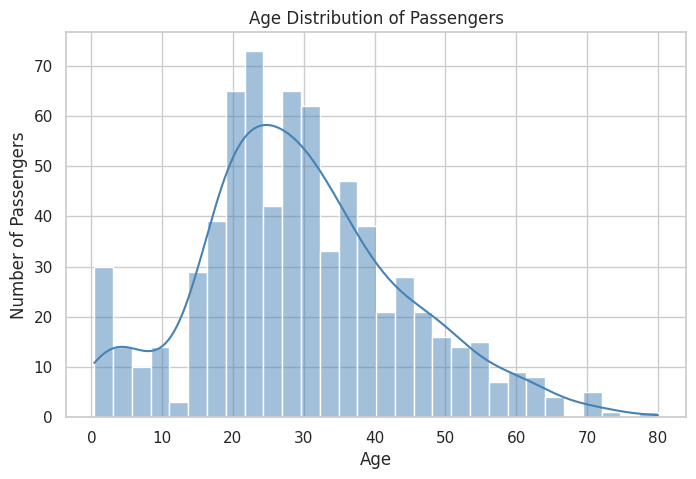

In [58]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


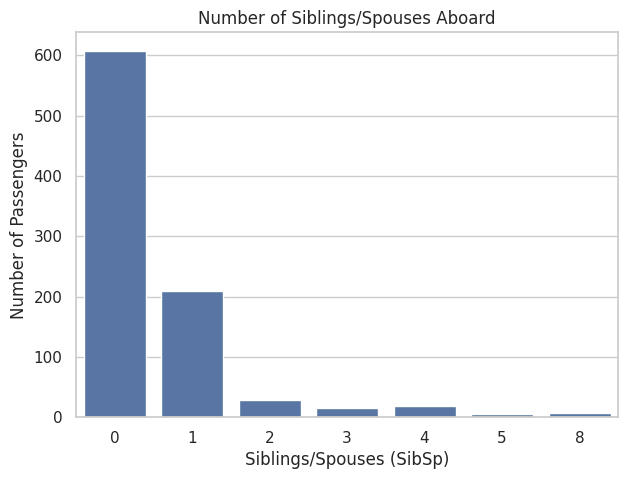

In [59]:
plt.figure(figsize=(7, 5))
sns.countplot(x="SibSp", data=df)
plt.title("Number of Siblings/Spouses Aboard")
plt.xlabel("Siblings/Spouses (SibSp)")
plt.ylabel("Number of Passengers")
plt.show()

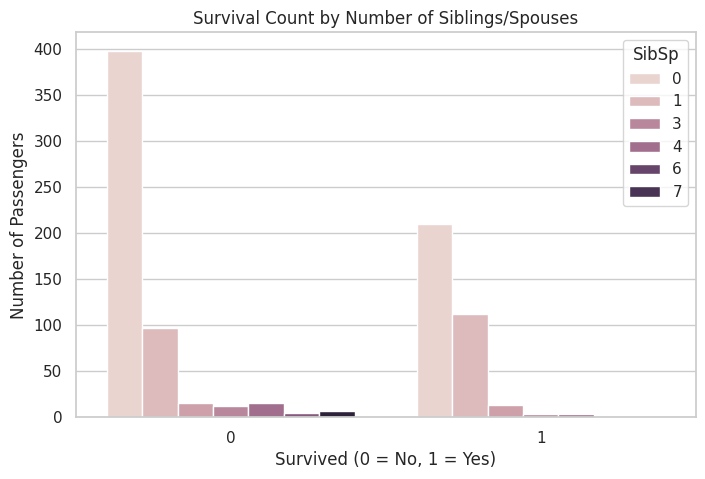

In [60]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Survived", hue="SibSp", data=df)
plt.title("Survival Count by Number of Siblings/Spouses")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.legend(title="SibSp")
plt.show()

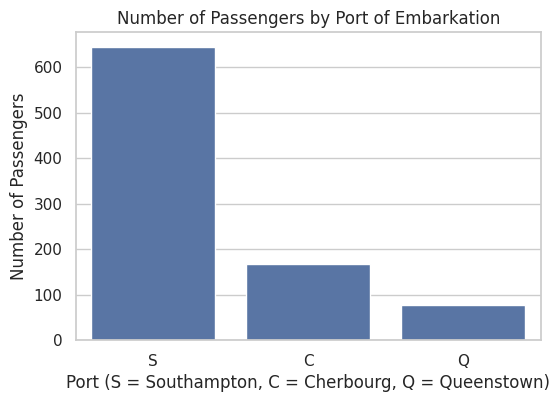

In [61]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Embarked", data=df)
plt.title("Number of Passengers by Port of Embarkation")
plt.xlabel("Port (S = Southampton, C = Cherbourg, Q = Queenstown)")
plt.ylabel("Number of Passengers")
plt.show()

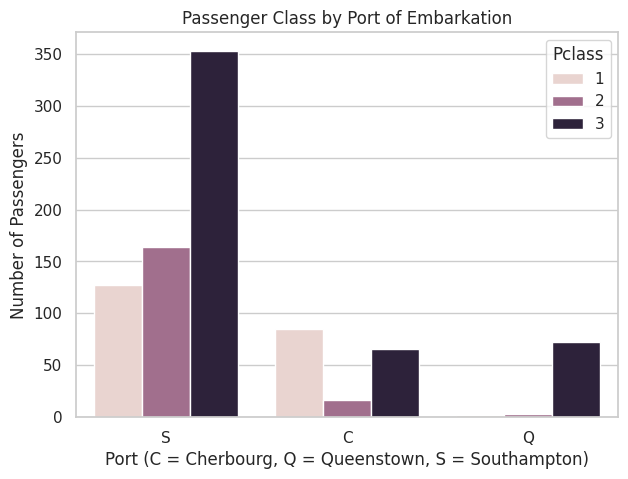

In [62]:
plt.figure(figsize=(7, 5))
sns.countplot(x="Embarked", hue="Pclass", data=df)
plt.title("Passenger Class by Port of Embarkation")
plt.xlabel("Port (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Number of Passengers")
plt.show()

**DATASET CLEANING**

In [63]:
df["Age"].mean()

np.float64(29.69911764705882)

In [64]:
df.groupby("Pclass")["Age"].mean()

,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


In [65]:
df["Age"] = df["Age"].fillna(df.groupby("Pclass")["Age"].transform("median"))

In [66]:
print("Missing Age:", df["Age"].isnull().sum())

Missing Age: 0


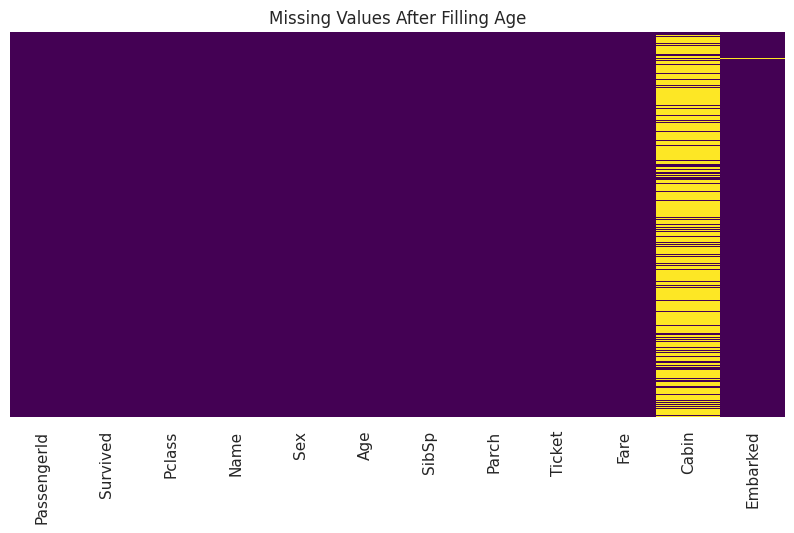

In [67]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values After Filling Age")
plt.show()

In [68]:
df.drop("Cabin", axis=1, inplace=True)

In [69]:
print(df.shape)

(891, 11)


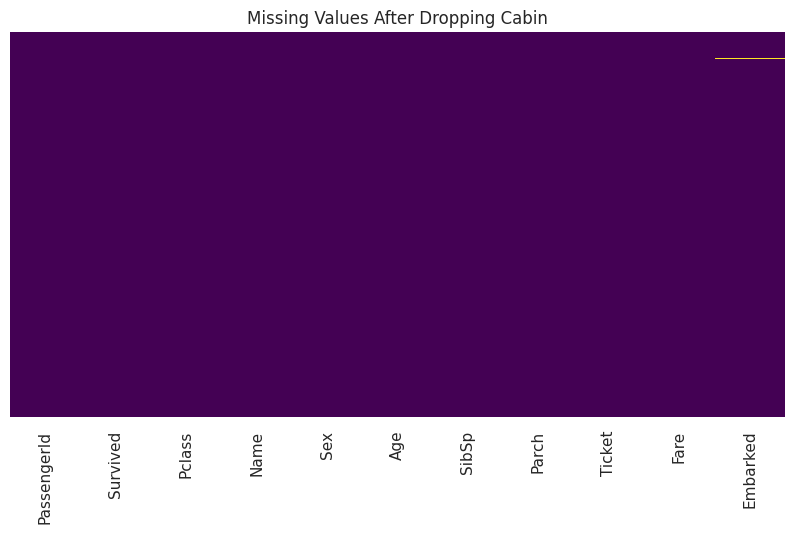

In [70]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values After Dropping Cabin")
plt.show()

In [71]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [72]:
print(df.isnull().sum())
print("Shape:", df.shape)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Shape: (891, 11)


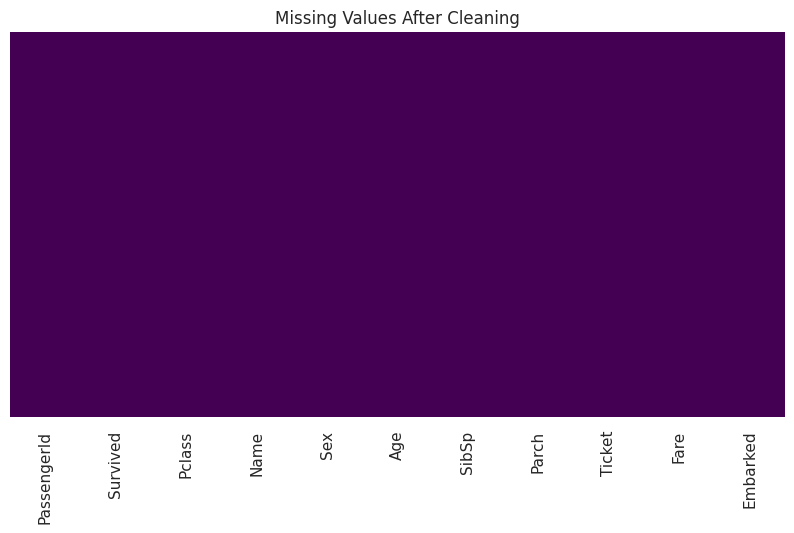

In [73]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Missing Values After Cleaning")
plt.show()

Remove Duplicates

In [74]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


Clean text and datatypes

In [75]:
df["Sex"] = df["Sex"].str.strip().str.lower()
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

Impossible values check

In [76]:
print("Negative age:", (df["Age"] < 0).sum())
print("Negative fare:", (df["Fare"] < 0).sum())

Negative age: 0
Negative fare: 0


In [77]:
print(df.isnull().sum())
print("Shape:", df.shape)
df.info()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Shape: (891, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(2), float64(2), int64(5), object(2)
memory usage: 64.8+ KB


### Cleaning Summary
- Dropped `Cabin` because about 77% of its values were missing.
- Filled 177 missing `Age` values with the median age of each passenger class.
- Filled 2 missing `Embarked` values with the most common port (S).
- Found no duplicate rows and no impossible values (negative age or fare).
- Cleaned the `Sex` text and converted `Sex` and `Embarked` to category type.
- `Fare` has a few very high values (up to 512), but these are real 1st class tickets, so they were kept.

In [78]:
print("Overall survival %:", round(df["Survived"].mean() * 100, 1))

print("\nSurvival % by Sex:")
print((df.groupby("Sex", observed=True)["Survived"].mean() * 100).round(1))

print("\nSurvival % by Pclass:")
print((df.groupby("Pclass")["Survived"].mean() * 100).round(1))

print("\nAverage Fare by Pclass:")
print(df.groupby("Pclass")["Fare"].mean().round(2))

Overall survival %: 38.4

Survival % by Sex:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

Survival % by Pclass:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64

Average Fare by Pclass:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64


**Observation:** Overall, only 38.4% of passengers survived. Women survived at 74.2% compared to just 18.9% for men. Survival also dropped with each lower class: 63.0% in 1st class, 47.3% in 2nd class and 24.2% in 3rd class. The average fare fell from 84.15 in 1st class to 13.68 in 3rd class.

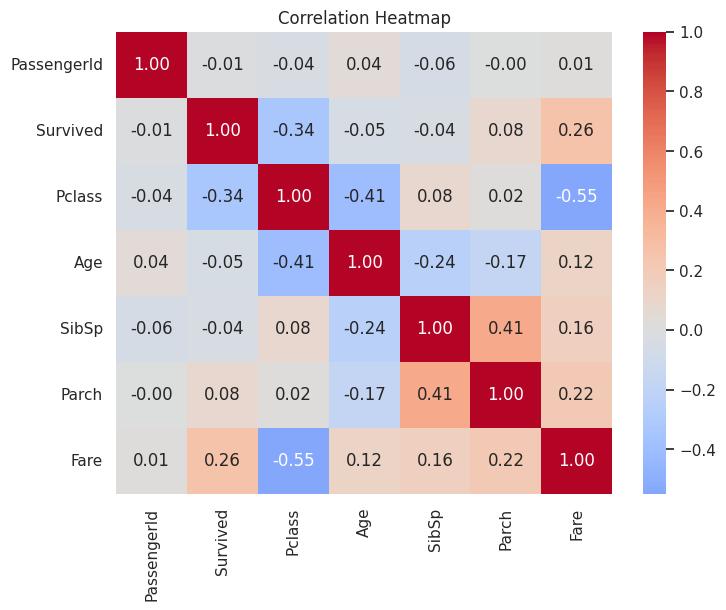

In [79]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Heatmap")
plt.show()

**Observation:** `Pclass` and `Fare` have the strongest correlation (-0.55): the lower the class number (1 = best), the higher the fare. `Survived` is negatively correlated with `Pclass` (-0.34) and positively with `Fare` (0.26), which fits the survival rates seen earlier. `Age` has almost no direct correlation with `Survived` (-0.05). Correlation shows a relationship, not cause and effect.

## Key Insights

### 1. Gender was the strongest factor in survival
**74.2% of women survived, compared to only 18.9% of men**, even though there were almost twice as many men on board (577 vs 314).

### 2. Passenger class strongly affected survival
**63.0% of 1st class passengers survived, vs 47.3% in 2nd class and only 24.2% in 3rd class.** Class and survival are negatively correlated (-0.34).

### 3. Fare and class are strongly linked
`Pclass` and `Fare` have a correlation of **-0.55**. The average fare fell from 84.15 in 1st class to 13.68 in 3rd class.

## Conclusion
Survival on the Titanic was not random. Gender and ticket class were the biggest factors, and the two were connected to each other.

## Limitations
- Missing ages were filled using class medians, which is an approximation.
- This analysis shows relationships, not proof of cause and effect.